<a href="https://colab.research.google.com/github/ZeinabSb/Intro-to-AI/blob/main/Lesson_5_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Assignment - EDA using Pandas**

***Instructions***
- Clone a copy of the assignment notebook in Google Colab.
- **Complete the tasks by filling in the code where indicated by TODO comments. Put each task in a new cell.**
- Run each cell to ensure your code works correctly.
- Pay attention to the output of each cell and interpret the results.
- For visualisation tasks, make sure to label axes, add titles, and choose appropriate colour schemes.
- After completing all tasks, review your findings and include notes of your insights gained from the EDA process as markdown notes for assessments.


In [9]:
# Titanic Dataset Exploratory Data Analysis

# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
url = "https://web.stanford.edu/class/archive/cs/cs109/cs109.1166/stuff/titanic.csv"

df = pd.read_csv(url)

df.head()

,Survived,Pclass,Name,Sex,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare
0,0,3,Mr. Owen Harris Braund,male,22.0,1,0,7.2500
1,1,1,Mrs. John Bradley (Florence Briggs Thayer) Cum...,female,38.0,1,0,71.2833
2,1,3,Miss. Laina Heikkinen,female,26.0,0,0,7.9250
3,1,1,Mrs. Jacques Heath (Lily May Peel) Futrelle,female,35.0,1,0,53.1000
4,0,3,Mr. William Henry Allen,male,35.0,0,0,8.0500


In [13]:
# Task 2: Inspect the data

# Display the first 5 rows of the dataset
print(df.head())

# Display the last 5 rows of the dataset
print(df.tail())

# Display the data types of each column
print(df.dtypes)

# Display summary statistics of the numerical columns
print(df.describe())

   Survived  Pclass                                               Name  \
0         0       3                             Mr. Owen Harris Braund   
1         1       1  Mrs. John Bradley (Florence Briggs Thayer) Cum...   
2         1       3                              Miss. Laina Heikkinen   
3         1       1        Mrs. Jacques Heath (Lily May Peel) Futrelle   
4         0       3                            Mr. William Henry Allen   

      Sex   Age  Siblings/Spouses Aboard  Parents/Children Aboard     Fare  
0    male  22.0                        1                        0   7.2500  
1  female  38.0                        1                        0  71.2833  
2  female  26.0                        0                        0   7.9250  
3  female  35.0                        1                        0  53.1000  
4    male  35.0                        0                        0   8.0500  
     Survived  Pclass                            Name     Sex   Age  \
882         0       2 

In [16]:
# Task 3: Clean and preprocess the data

# Create a new categorical feature 'PclassCategory' from 'Pclass'
df['PclassCategory'] = df['Pclass'].map({
    1: 'First Class',
    2: 'Second Class',
    3: 'Third Class'
})

# Handle missing values in the 'Age' column using the mean age
df['Age'] = df['Age'].fillna(df['Age'].mean())



In [17]:
# Task 4: Identify specific data points

# Find passengers with the highest fare
highest_fare_passengers = df[df['Fare'] == df['Fare'].max()]

print("Passengers with the highest fare:")
print(highest_fare_passengers)

Passengers with the highest fare:
     Survived  Pclass                               Name     Sex   Age  \
257         1       1                    Miss. Anna Ward  female  35.0   
676         1       1  Mr. Thomas Drake Martinez Cardeza    male  36.0   
733         1       1              Mr. Gustave J Lesurer    male  35.0   

     Siblings/Spouses Aboard  Parents/Children Aboard      Fare PclassCategory  
257                        0                        0  512.3292    First Class  
676                        0                        1  512.3292    First Class  
733                        0                        0  512.3292    First Class  


In [18]:
# Task 5: Demonstrate Pandas Series and DataFrame functionalities

# Create a Pandas Series of passenger names
names_series = df['Name']

# Create a DataFrame of passenger names and ages
names_ages_df = df[['Name', 'Age']]

# Slice the DataFrame to show only passengers older than 50
older_passengers = df[df['Age'] > 50]

# Display the results
print("Passenger names (Series):")
print(names_series)

print("\nPassenger names and ages (DataFrame):")
print(names_ages_df)

print("\nPassengers older than 50:")
print(older_passengers)

Passenger names (Series):
0                                 Mr. Owen Harris Braund
1      Mrs. John Bradley (Florence Briggs Thayer) Cum...
2                                  Miss. Laina Heikkinen
3            Mrs. Jacques Heath (Lily May Peel) Futrelle
4                                Mr. William Henry Allen
                             ...                        
882                                 Rev. Juozas Montvila
883                          Miss. Margaret Edith Graham
884                       Miss. Catherine Helen Johnston
885                                 Mr. Karl Howell Behr
886                                   Mr. Patrick Dooley
Name: Name, Length: 887, dtype: object

Passenger names and ages (DataFrame):
                                                  Name   Age
0                               Mr. Owen Harris Braund  22.0
1    Mrs. John Bradley (Florence Briggs Thayer) Cum...  38.0
2                                Miss. Laina Heikkinen  26.0
3          Mrs. Jacques H

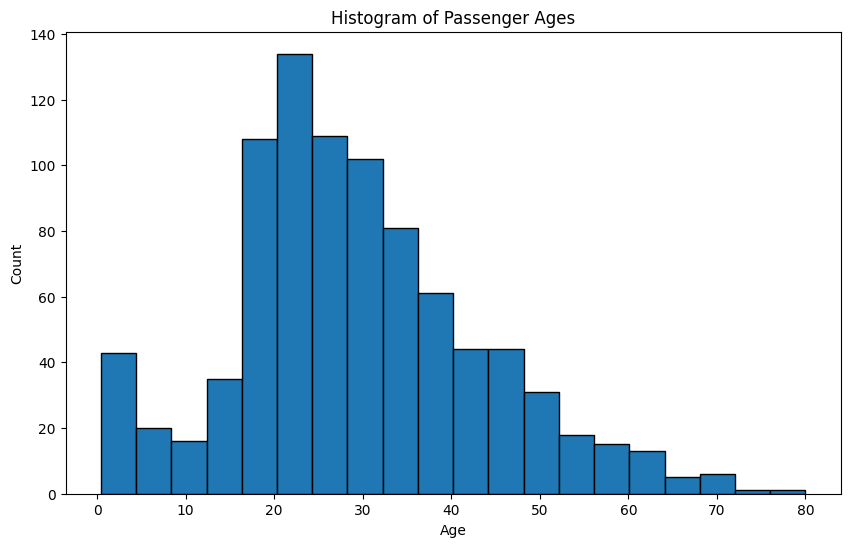

In [21]:
 #Create a histogram of passenger ages
plt.figure(figsize=(10, 6))
plt.hist(df['Age'], bins=20, edgecolor='black')
plt.title('Histogram of Passenger Ages')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()






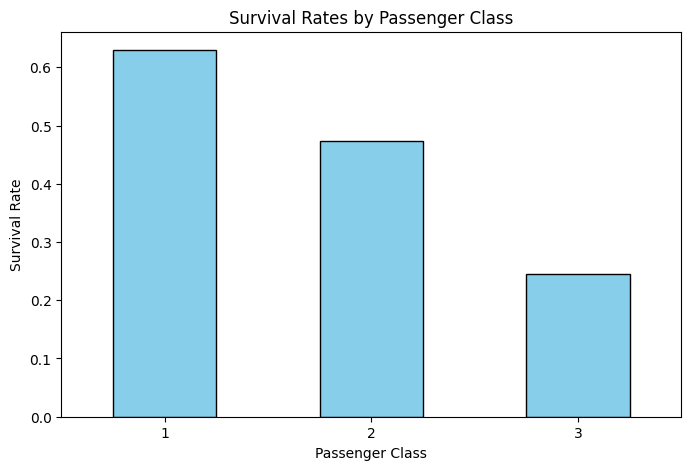

In [22]:
# Create a bar plot of survival rates by passenger class
survival_rates = df.groupby('Pclass')['Survived'].mean()

plt.figure(figsize=(8, 5))
survival_rates.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Survival Rates by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate')
plt.xticks(rotation=0)
plt.show()





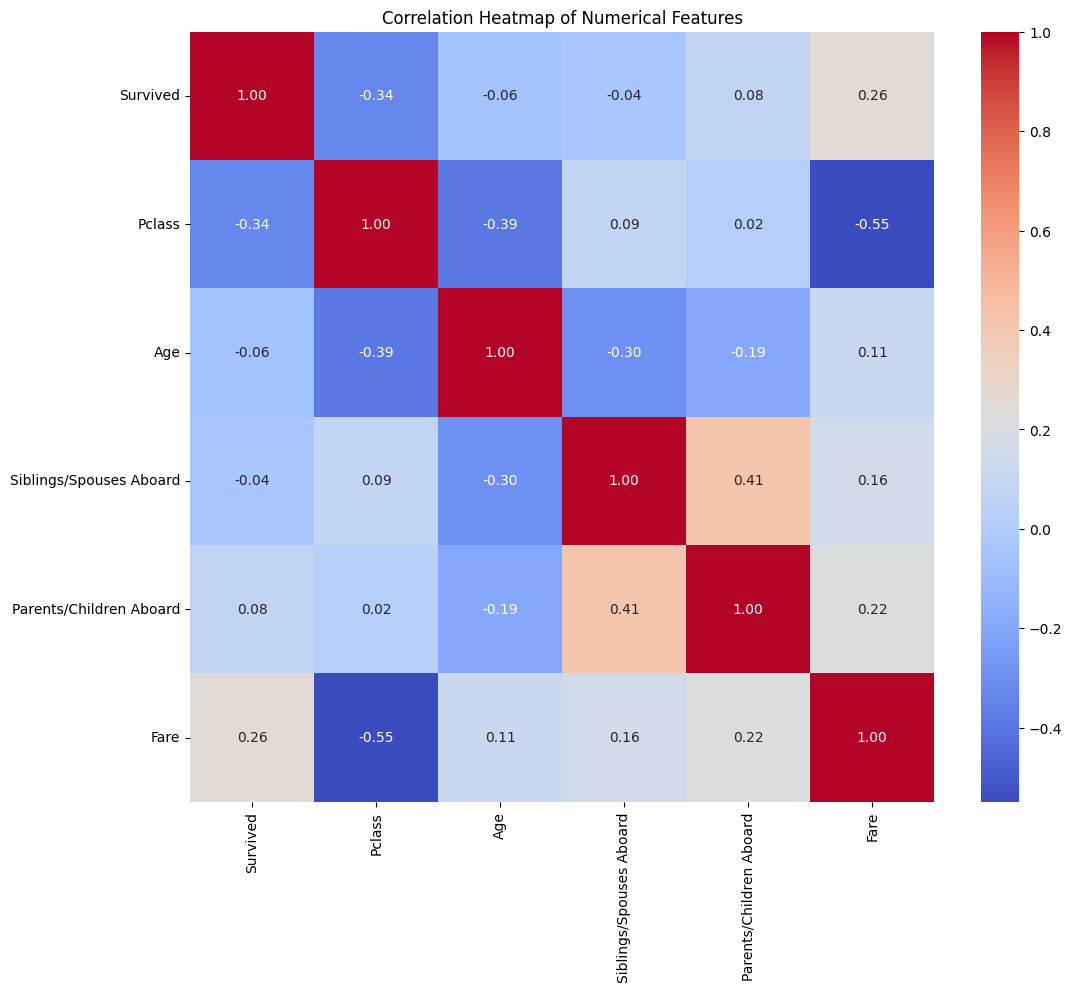

In [23]:
# Create a heatmap of correlation between numerical features
plt.figure(figsize=(12, 10))
correlation = df.select_dtypes(include='number').corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()